# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.1 Базовая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с базовыми подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за эту часть — 6 баллов. Детальнее про оценивание — в самом конце ноутбука.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-base-Username.ipynb**, где Username — ваша фамилия.

### **Сетап**

<img style="float: right; padding-right:15px; padding-bottom:10px" src="https://i.postimg.cc/26KqqSb2/pomoika2.png" height=300px width=200px alt="Pomoika 2">
    
В этом домашнем задании мы будем работать с задачей классификации, но сконцентрируемся на том, что приносит не меньшую пользу, чем сами модели — замешиванию данных.

Целевая метрика уже выбрана за нас: мы будем считать $\text{ROC-AUC}$, но не простой, а коэффициент Джини:

$$ \text{Gini} = 2 \cdot \text{ROC-AUC} - 1$$

Конечная цель данного мероприятия — собрать пайплайн машинного обучения от и до, начиная с предобработки данных, заканчивая оптимизацией. При желании это можно доделать до целого пет-проекта, особенно если добавить сбор данных и деплой модели, но в дз этого не будет :(.

Цель конкретно базового ноутбука — познакомить вас с основными преобразованиями и собрать солидный фундамент для преобразований посложнее. 

In [2]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

#### **Данные**

У вас на руках (на Kaggle) датасет по широко известной в неузких кругах видеоигре Dota 2, скачанный через OpenDota API и заботливо анонимизированный. Если вы не знакомы с игрой — ничего страшного, все необходимое для заданий в базовой части мы подробно опишем.

Нас интересует исход матча — победа или поражение, исходя из совершенно разных факторов (например, чтобы делать ставки на спорт, осуждаем?). Это информация о сессии, игроках, героях, и т д. **в первые 15 минут** после начала матча.

Краткая сводка об игре:

- Dota 2 — командная игра: 5 игроков за Свет (Radiant) против 5 за Тьму (Dire).
- Каждый игрок управляет уникальным героем со своим набором атрибутов и способностей.
- Цель — снести главную постройку на вражеской базе (в простонародье трон).
- В процессе матча игроки добывают золото и опыт, покупают предметы и убивают противников, чтобы стать сильнее.
- Ничьих не бывает, фиксированного таймера нет — матч длится до падения трона.

#### 📌 **Важнейшее замечание**

Предполагается, что у вас уже сложилось понимание:
- как крутить и вертеть данные, чтобы фиты делались твёрдо, трансформы ложились чётко, шейпы датафреймов стакались и нужные джойны джойнились;
- как рисовать читаемые графики;
- как проверять качество модели;

Пожалуйста, следите за этим очень-очень внимательно, иначе рискуете получить штраф и всеобщее порицание в нашем уютном МО-1 чатике (хотя, у этого есть плюсы).

Если возникнут вопросы по игровой части — **не стесняйтесь** спрашивать, гуглить, обращаться к GPT или, прости Господи, дотерам. Знание области — важнейшая составляющая хорошего фича инжиниринга

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Для лучшего понимания, в голубеньких пунктах будет небольшое <font color="#647cb8">**обоснование**</font> того, зачем вообще делается то или иное преобразование (в колабе придётся включать интуицию, там не работает HTML). Вы можете её скипнуть, если всё понятно и без этого

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

В пунктах с розоватой, как у всеми любимого Pudge, расцветкой мы попросим вас написать <font color="#f68c9d">**Ответ**</font> на <font color="#f68c9d">**Вопрос**</font> или <font color="#f68c9d">**рефлексию**</font>, которая должна направить вашу мысль о том, как варить фичи, в нужном направлении. Уметь аргументировать свою точку зрения важно не менее

Пожалуйста, даже если вы уже прожжённый дед инсайд и дата-сайентист 14 уо, всё равно <font color="#f68c9d">**порефлексируйте**</font>. Количество потерянных нервных клеток и ваш успех на соревновании напрямую зависят от базовой предобработки.
Вы **можете** писать <font color="#f68c9d">**её**</font> ёмко, но только если **знаете** ответ

</div>

<div style="border-left: 5px solid #cb9255; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(200, 156, 105, 0.05);">

<font>По ходу домашки вам придётся делать <font color="#cb9255">**выборы**</font> и подбирать <font color="#cb9255">**гиперпараметры**</font>. Какие-то из них важнее остальных. У ряда выборов последствия чисто номинальные, какие-то видоизменят другие задания, третьи полностью определят, как вы будете делать остальную домашку. 

Принимайте решения мудро. Не привязывайтесь к ним слишком сильно, возможно, в процессе вам захочется пересмотреть ваши жизненные приоритеты. Пробуйте, экспериментируйте, фичи это самое творческое, что есть в машинном обучении

При желании, в конце обоих ноутбуков есть инструменты, которые, при остром желании и избытке свободного времени, могут тупо перебрать все выборы и найти самый оптимальный, но это опционально
</div>

### **Часть 1. Это, так сказать, база. (3.25 балла)** <img align="center" height=28 width=28 src="https://media.tenor.com/5vGX5VO-IxsAAAAi/arthas.gif">

В которой студент учится смотреть на фичи под правильным углом и готовить из сырых данных простые, но аппетитные факторы

#### **Задание 1.1. Датасет** (0.5 балла)

Чтобы начать работу с данными, эти данные сперва нужно [загрузить](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105). Пока что нам потребуются лишь:

1. Информация о матчах - `matches_df_train.csv`.
2. Тестовые данные для соревнования - `matches_df_test.csv`.

Посмотрите на все csv-файлы выше, создайте под каждый из них отдельный датафрейм и отметьте (текстом или кодом):
- объемы таблиц: как в Мб, так и `df.shape`
- какие в них есть колонки по своему содержанию

In [3]:
import pandas as pd

df_train = pd.read_csv("data\matches_df_train.csv")
df_test = pd.read_csv("data\matches_df_test.csv")

In [4]:
print(f'Размеры таблицы train: {df_train.shape}')

print(f'Размеры таблицы test: {df_test.shape}')

Размеры таблицы train: (641090, 7)
Размеры таблицы test: (59748, 5)


In [5]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 641090 entries, 0 to 641089
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   match_id     641090 non-null  int64  
 1   date         641090 non-null  str    
 2   region       641090 non-null  str    
 3   game_mode    641090 non-null  int64  
 4   duration     641090 non-null  int64  
 5   radiant_win  641090 non-null  bool   
 6   avg_mmr      472334 non-null  float64
dtypes: bool(1), float64(1), int64(3), str(2)
memory usage: 30.0 MB


In [6]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 59748 entries, 0 to 59747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   match_id   59748 non-null  int64  
 1   date       59748 non-null  str    
 2   region     59748 non-null  str    
 3   game_mode  59748 non-null  int64  
 4   avg_mmr    44504 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 2.3 MB


Размеры таблицы `train`: 30 Мб

Размеры таблицы `test`: 2.3 Мб

Отдельно хочется посмотреть распределение целевой переменной, покажите его, пожалуйста

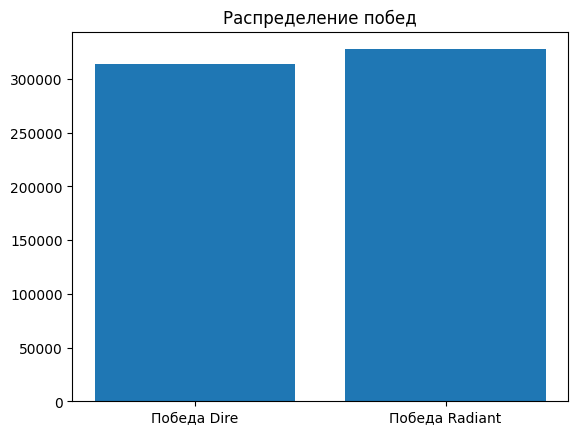

In [7]:
import matplotlib.pyplot as plt

data = df_train['radiant_win'].value_counts().sort_index()
plt.bar(['Победа Dire', 'Победа Radiant'], data.values)
plt.title("Распределение побед")
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** подходящая ли в данном случае метрика $\text{Gini}$ в сравнении, например, с $\text{AUC-PR}$?

**Ответ:**

Да, Gini должен отлично подойти, потому что в нашем случае не должно быть сильного дисбаланса классов, что и показывает распределение: побед Dire и Radiant примерно 50 на 50. 

AUC-PR нужен при дисбалансе классов, у нас тут такого нет

</div>

#### **Задание 1.2. Категории** (0.75 балла)

Чтобы построить реально балдёжную модель, зачастую не получится просто написать фит предикт. О нет, это долгая и утомительная возня. А если нужно ещё и отчётики писать, то хоть <span style="color:grey"><font size="1">~~вешайся (осуждаем)~~ </font></span> увольняйся. Так и здесь. И того, что есть, уже хватит, чтобы продемонстрировать глубокую и тёмную сторону Dota Science.

В целом, данные уже содержат признаки, по которым что-то даже можно построить, в частности — регионы.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

У Radiant, по сравнению с Dire, исторически есть небольшое преимущество — чуть удобнее карта, порядок выбора героев и всё такое. В разных регионах бывают разные предпочтения по стилям игры и тактикам, и где-то это преимущество реализуют лучше

</div>

Посмотрите, где у нас содержится информация о регионе, на серверах которого был проведён матч, и постройте 2 графика:
1) Распределение регионов (процентное и абсолютное) на тренировочных и тестовых данных
2) Среднее значение таргета на трейне, в зависимости от региона

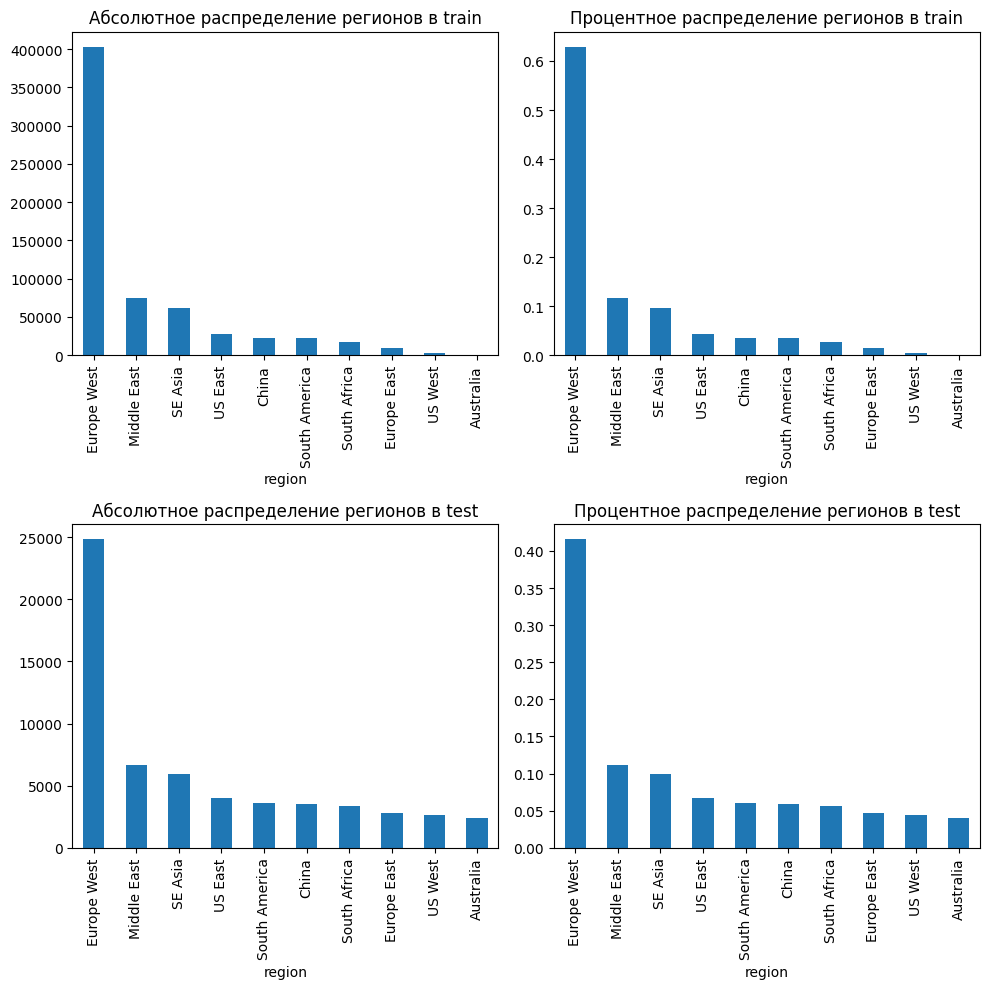

In [8]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
df_train["region"].value_counts().plot.bar()
plt.title("Абсолютное распределение регионов в train")

plt.subplot(2, 2, 2)
df_train["region"].value_counts(normalize=True).plot.bar()
plt.title("Процентное распределение регионов в train")

plt.subplot(2, 2, 3)
df_test["region"].value_counts().plot.bar()
plt.title("Абсолютное распределение регионов в test")

plt.subplot(2, 2, 4)
df_test["region"].value_counts(normalize=True).plot.bar()
plt.title("Процентное распределение регионов в test")

plt.tight_layout()
plt.show()

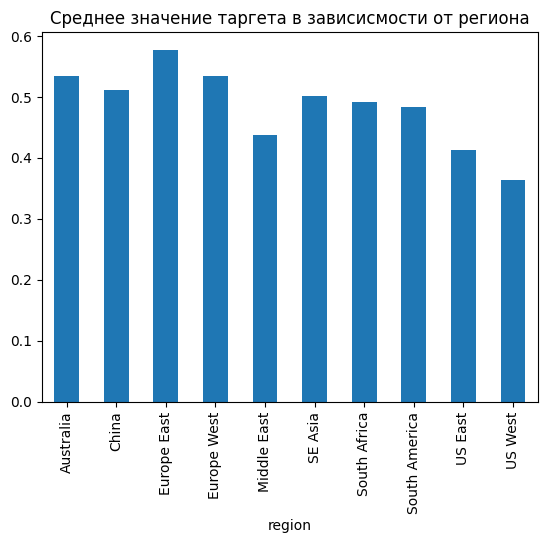

In [9]:
df_train.groupby("region")["radiant_win"].mean().plot.bar()
plt.title("Среднее значение таргета в зависисмости от региона")
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы можете сказать о распределении регионов? Объясните, получится ли вообще обучить по нему модель, есть ли там сигнал?

**Ответ:**  

Распределение по регионам показывает, что данные несбалансированы. Особенно это заметно в train, где больше 60% выборки из региона Europe West, а многие другие регионы занимают 5% или меньше процентов. Test чуть более равномерный, но всё равно с большим перевесом West Europe.

Это говорит о том, что модель будет обучаться преимущественно на матчах из West Europe, и значит, будет давать плохие прогнозы для остальных регионов.

Средние значения таргета колеблятся в зависимости от региона и разница в средних значениях таргета составляет до 20 процентных пунктов, так что сигнал есть, хотя может и не очень сильный.

</div>


Наша первая развилка — <font color="#cb9255">**выбор**</font>, какой из энкодеров стащить. Рекомендуется брать что-то из `category_encoders`, они похожи на стандартные из `sklearn`, но их больше и применять их проще.

| <font color="#cb9255">**One-Hot Encoder**</font> | <font color="#cb9255">**Target Encoder**</font> |
| :--- | :--- |
| Превращает категориальный признак в вектор из 0 и 1.  <br> 1 стоит на месте i‑го индекса, если у объекта есть i‑е значение признака. | Кодирует категориальный признак средним значением таргета.  <br> Среднее считается по всем объектам с i‑м значением признака. |

Можно взять и другой, но морально готовьтесь получить $\text{Gini} = 0$
</div>

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Без энкодинга использовать категориальные признаки в линейных моделях, увы, нельзя, выбор без выбора 

</div>

In [49]:
#!pip install -qU category-encoders

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какой из энкодеров кажется вам наиболее привлекательным? Почему?

**Ответ:**

Я возьму `One-Hot Encoder`, потому что
1) У признака region всего 10 значений, а значит, таблица не сильно увеличится в размерности
2) По распределению было видно, что всех регионов, кроме West Europe, не так много, поэтому данные могут содержать шум, и если мы заполним средними значениями по ним, возможно будет переобучение под эти данные


</div>

Закодируйте колонку `region` выбранным вами способом

In [10]:
import category_encoders as ce

encoder = ce.OneHotEncoder(cols=['region'])
data_train = encoder.fit_transform(df_train)

encoder = ce.OneHotEncoder(cols=['region'])
data_test = encoder.fit_transform(df_test)

#### **Задание 1.3. Даты** (1.25 балла)

Если нам хочется видеть будущее, именно время диктует, что брать можно, а что никак нельзя

Найдите колонку дат на тренировочных данных и:
1. Постройте график доли побед Radiant в зависимости от даты матча
2. Сравните временные диапазоны на трейне и тесте

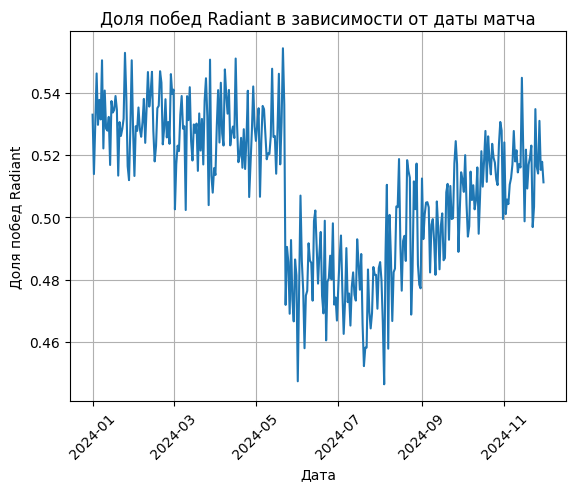

In [11]:
data = data_train.groupby(pd.to_datetime(data_train['date']))['radiant_win'].mean()

plt.plot(data.index, data.values)
plt.xlabel("Дата")
plt.ylabel("Доля побед Radiant")
plt.title("Доля побед Radiant в зависимости от даты матча")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [12]:
print(f"Диапозон дат train: с {data_train['date'].min()} по {data_train['date'].max()}")
print(f"Диапозон дат test: с {data_test['date'].min()} по {data_test['date'].max()}")

Диапозон дат train: с 2024-01-01 по 2024-11-30
Диапозон дат test: с 2024-12-01 по 2024-12-31


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** видите ли вы какой-то паттерн в распределении дат? Можете ли вы объяснить при помощи сети Интернет, что там произошло? \
(Подсказка: соревновательные игры периодически обновляются)

**Ответ:**

Примерно до июня 2024 доля побед Radiant не менялась - значения преимущественно колебались между 0.52 и 0.54, однако в июне доля побед резко снизилась до 0.47 - 0.49, после чего она начала снова постепенно возрастать, почти достигнув изначальных значений к концу 2024 года.

Сеть Интернет подсказала, что секрет тут в том, что в мае 2024 года вышло крупное обновление, появились новые механики, произошли изменения в героях, картах, экономике, из-за чего противоположная сторона временно получила преимущество, пока игроки не адаптировали свои стратегии к произошедшим изменениям.


</div>

Теперь давайте что-нибудь повыделяем.

<div style="border-left: 5px solid #5584a8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Даты сами по себе это всегда очень простые фичи, функционал есть в любой библиотеке. Связь с таргетом может быть, но не обязана. Именно даты проверить легко и быстро, зависимости бывают неожиданными. Впрочем, это не единственная причина, не переключайтесь

</div>

С таймстемпом можно делать не так много, кроме базовых манипуляций:

1. Вытащите лежащую на поверхности информацию, например, день и день недели. Хватит и этих двух
2. Посмотрите сами на список возможных признаков, будь то [pandas](https://pandas.pydata.org/docs/user_guide/timeseries.html#time-date-components) или [polars](https://docs.pola.rs/api/python/stable/reference/expressions/temporal.html), и <font color="#cb9255">**либо добавьте**</font> 2 признака, которые, как вам кажется, сработают, <font color="#cb9255">**либо поясните**</font>, почему это ничего не даст

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** необходимо ли кодировать признаки из дат? Если да, то какие и как? Если нет, то почему? </font>

**Ответ:** 

Не хочется брать большие временные промежутки такие, как `month` или `quater`, так как у нас данные за год, а значит, модель может сильно переобучится под ту ситуацию с обновлением (нет данных по месяцам других лет). Плюс до обновления видно, что в масштабе месяца изменений особо нет, и колебания происходили на уровне дней или недель. Поэтому, думаю, что признаков `day` и `weekday` нам будет достаточно

Признак `day` кодировать смысла нет, так как достаточно много категорий. 

Признак `weekday` лучше закодировать с помощью OneHotEncoding, чтобы модель не могла сравнивать между собой дни недели.

</div>

3. Закодируйте новые признаки, согласно вашему ответу

In [13]:
data_train['date'] = pd.to_datetime(data_train['date'])
data_test['date'] = pd.to_datetime(data_test['date'])

data_train['day'] = data_train['date'].dt.day
data_train['weekday'] = data_train['date'].dt.weekday

data_test['day'] = data_test['date'].dt.day
data_test['weekday'] = data_test['date'].dt.weekday

enc_train_weekday = ce.OneHotEncoder(cols=['weekday'])
data_train = enc_train_weekday.fit_transform(data_train)

enc_test_weekday = ce.OneHotEncoder(cols=['weekday'])
data_test = enc_test_weekday.fit_transform(data_test)

Кажется, мы что-то забыли... Ах да, надо бы и модель обучить, вот только без валидации это будет как-то не по-моповски, надо озаботиться этим вопросом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

На самом деле временная структура нужна не столь, чтобы вытащить какие-то признаки, сколько, чтобы понять распределение и изменение данных во времени же. Даты играют в этом прямую роль

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** почему здесь будет не лучшим решением брать случайное разбиение на трейн и валидацию?

**Ответ:**

Если мы случайно будет разбивать на трейн и валидацию, даты матчей перемешаются. А нам нужно, чтобы в трейн входили более ранние матчи, а в валидацию более новые, потому что мы хотим обучаться на данных из прошлого, чтобы предсказывать будущее. Это важно, так как игра постоянно меняется, и было бы славно, если бы модель вела себя хорошо именно на новых данных. 

</div>

Тут выбор у вас решили отобрать, делать мы будем OOT валидацию. Впрочем, какие-то опции ещё остались

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">OOT (Out-of-Time)</font>
    </th>
    <th width="50%">
      <font color="#cb9255">CV OOT (Cross-Validation Out-of-Time)</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Валидация с одной отложенной подвыборкой, <br>
      взятой после трешхолда t. Простая, как палка, <br>
      но если валидация получится грустной — <br>
      аномальной, нетипичной, маленькой, — <br>
      то и метрика ваша тоже будет грустной.
    </td>
    <td valign="top">
      Кросс-валидация с k разбиениями по времени <br>
      с итеративным расширением исходного фолда. <br>
      Оценка метрики сместится куда меньше <br>
      по сравнению с плохим сплитом OOT, <br>
      но это долго, если фолдов много.
    </td>
  </tr>
  <tr>
    <td valign="top">
      <code>sklearn.model_selection.train_test_split</code>
    </td>
    <td valign="top">
      <code>sklearn.model_selection.TimeSeriesSplit</code>
    </td>
  </tr>
</table>



Настройте любой из видов валидации (<font color="#cb9255">**трешхолд**</font> `t` или <font color="#cb9255">**число фолдов**</font> <code>n_folds</code></font> подберите сами). Они оба должны показывать качество адекватно, хотя второй теоретически должен быть более обоснован. CV-OOT не даст вам бонусов, но кто знает, за какие крохи Джини придётся бороться на соревновании?

In [14]:
from sklearn.model_selection import TimeSeriesSplit

data_train = data_train.sort_values('date')
y = data_train['radiant_win']
X = data_train.drop(columns = ['radiant_win'])

tscv = TimeSeriesSplit(n_splits=5)


И вот теперь мы уже наконец-то будем что-то обучать. Моделей классификации мы знаем как минимум две — SVM и логистическую регрессию, но есть нюанс.

Выборы, выборы..:

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">Dedicated model</font>
    </th>
    <th width="50%">
      <font color="#cb9255">Gradient Descent</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Большой разницы между <code>LogisticRegression</code> и <code>LinearSVC</code> <br>
      из <code>sklearn.linear_model</code> на самом деле нет: <br>
      разделяющие поверхности очень похожи, <br>
      оба хорошо оптимизированы специальными солверами.
    </td>
    <td valign="top">
      Градиентный спуск через <code>sklearn.linear_model.SGDClassifier</code> <br>
      с параметрами <code>loss="log_loss"</code> или <code>loss="hinge"</code> — <br>
      очень соблазнительная альтернатива, но!
    </td>
  </tr>
  <tr>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Обучать и применять их в разы проще, <br>
      фит–предикт делает брр. <br>
      <font color="#cb9255"><b>−</b></font> Они используют сразу всю выборку <br>
      для обучения, а в ходе задания наша выборка <br>
      может вырасти раз так в 1000, немало!
    </td>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Влезет любой датасет. <br>
      <font color="#cb9255"><b>+</b></font> Бóльший контроль над процессом обучения. <br>
      <font color="#cb9255"><b>−</b></font> Обучать на больших данных <br>
      (скорее про часть <b>advanced</b>) придётся через <code>partial_fit</code>, неудобно. <br>
      <font color="#cb9255"><b>−</b></font> Нужно подбирать больше гиперпараметров.
    </td>
  </tr>
</table>


Выберите <font color="#cb9255">**одну из**</font> моделей выше (хотя `LinearRegression` <font color="#cb9255">**тоже можно**</font>, если у вас сегодня авантюрное настроение, успех не гарантирован, о рисках узнаете на лекции) **(обращаем внимание, что другие варианты запрещены)**. Обучите по одному экземпляру на группах признаков:

- дат
- регионов
- дат и регионов

Ну и замерьте качество!

<font color="#cb9255">**NB**</font>: 

1. Вы сразу можете строить роскошный пайплайн обучения, а не делать по кускам в отдельных блоках, про это есть **advanced** пункт (**6.1**) на 0.5 баллов
2. Если у вас есть GPU, то почему бы его и не [использовать](https://docs.rapids.ai/api/cuml/stable/)? Если гпу у вас нет, у вас теперь точно есть Kaggle, который щедро дарит 30 часов гпу в неделю, пользуйтесь на здоровье, за это есть маленький, но приятный буст на 0.25 балла (**пункт 6.3**)
3. Наконец, если вы сразу оформите хранилище для результатов запусков ваших моделей, вы снова получите 0.25 балла (**пункт 6.2**)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

dates = ['day'] + [col for col in X.columns if col.startswith('weekday')]
regions = [col for col in X.columns if col.startswith('region')]
dates_regions = dates + regions

res = {
    'dates': [],
    'regions': [],
    'dates_regions': []
}

for train_idx, val_idx in tscv.split(X):
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model_dates = LogisticRegression(max_iter=1000)
    model_dates.fit(X_train[dates], y_train)
    pred_dates = model_dates.predict_proba(X_val[dates])[:, 1]
    score_dates = roc_auc_score(y_val, pred_dates)
    res['dates'].append(score_dates)

    model_regions = LogisticRegression(max_iter=1000)
    model_regions.fit(X_train[regions], y_train)
    pred_regions = model_regions.predict_proba(X_val[regions])[:, 1]
    score_regions = roc_auc_score(y_val, pred_regions)
    res['regions'].append(score_regions)

    model_dates_regions = LogisticRegression(max_iter=1000)
    model_dates_regions.fit(X_train[dates_regions], y_train)
    pred_dates_regions = model_dates_regions.predict_proba(X_val[dates_regions])[:, 1]
    score_dates_regions = roc_auc_score(y_val, pred_dates_regions)
    res['dates_regions'].append(score_dates_regions)

res_df = pd.DataFrame(res)

In [19]:
total_res = {
    'dates' : np.mean(res['dates']),
    'regions': np.mean(res['regions']),
    'dates_regions' : np.mean(res['dates_regions'])
}

print(f"Среднее значение ROC-AUC для дат: {total_res['dates']}")
print(f"Среднее значение ROC-AUC для регионов: {total_res['regions']}")
print(f"Среднее значение ROC-AUC для дат и регионов: {total_res['dates_regions']}")

Среднее значение ROC-AUC для дат: 0.503143445295702
Среднее значение ROC-AUC для регионов: 0.5376469363333787
Среднее значение ROC-AUC для дат и регионов: 0.5390197929980133


In [20]:
res_df

,dates,regions,dates_regions
0,0.504146,0.535445,0.536973
1,0.503426,0.537397,0.538985
2,0.502949,0.538340,0.539803
3,0.504722,0.540336,0.542085
4,0.500473,0.536717,0.537253


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** помогли ли даты? А должны? Хотите ли вы их оставить?

**Ответ:**

Когда модель обучалась только на датах, она давала результаты около 0.5, а значит, работала почти так рандом. Но они и не должны были давать сильный вклад, потому что нет какой-то прямой связи между датам и победами в матчах. 

Однако, если посмотреть на результаты модели, обученной на регионах и датах, можно заметить, что на всех выборках значение чуть улучшилось по сравнению с просто регионами. Эффект несильно большой, даты помогли улучшить результат в среденем на 0.001, поэтому я бы не брала эти признаки, их вклад слишком слабый.

</div>

In [21]:
X = X.drop(columns=dates)
data_test = data_test.drop(columns=dates)
data_train = data_train.drop(columns=dates)

#### **Задание 1.4. Числа** (0.75 балла)

Остался неотвеченным лишь один вопрос — а что числовые признаки? С ними всё одновременно и проще, и сложнее.

Найдите, где хранится средний ммр матча — это средний рейтинг игроков, которые в нём участвовали, чем выше, тем лучше.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

От ммра напрямую зависит то, как игроки пользуются естественным преимуществом Radiant. Чем игроки сильнее, тем чаще это должно происходить, в теории

</div>

Сделайте (на трейне, валидации и тесте) вот что :
1. Постройте график распределения ммров
2. Сравните, насколько распределения похожи между собой визуально

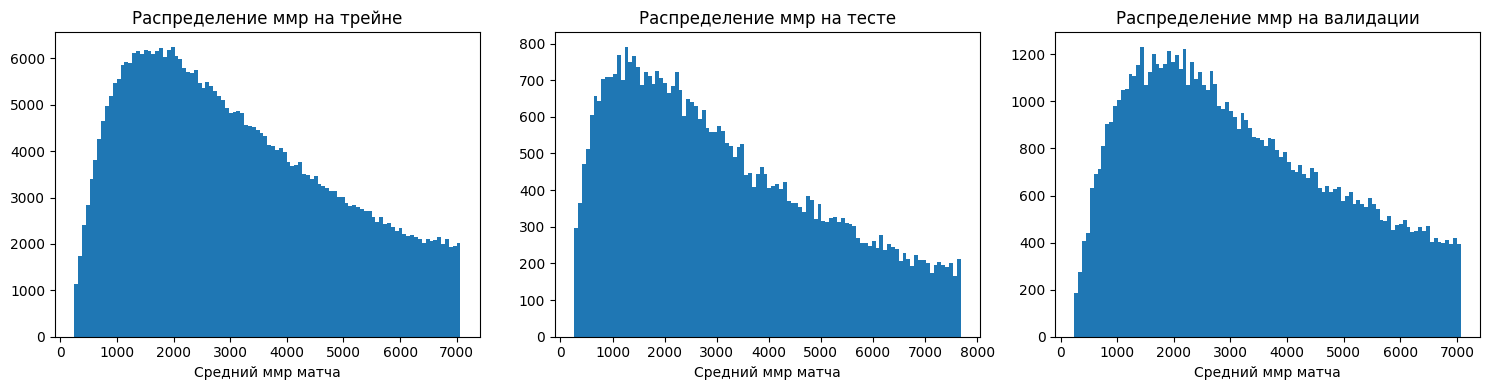

In [22]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(X_train['avg_mmr'], bins=100)
plt.xlabel('Средний ммр матча')
plt.title('Распределение ммр на трейне')

plt.subplot(1, 3, 2)
plt.hist(data_test['avg_mmr'], bins=100)
plt.xlabel('Средний ммр матча')
plt.title('Распределение ммр на тесте')

plt.subplot(1, 3, 3)
plt.hist(X_val['avg_mmr'], bins=100)
plt.xlabel('Средний ммр матча')
plt.title('Распределение ммр на валидации')

plt.tight_layout()
plt.show()

Распределения довольно сильно похожи:
- у них всех пик около ммр 1500-2000
- почти одинковый разброс: от 300 до 7000-7500
- схожая форма, только у трейна чуть более гладкая, но это лишь из-за того, что там выборка больше

То есть, всё хорошо - разбиение сохранило структуру данных

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бы вы описали это распределение в целом, похоже ли оно на что-то знакомое вам? 

**Ответ:** 

Распределение несимметричное, оно скошено вправо: сначала сильно растёт, достигает пик, а дальше начинает медленно убывать. Похоже на `логнормированное распределение`.

</div>

Кто-то где-то говорил, что числовые признаки надо бы стандартизировать, чтобы вышло что-то годное. Этот кто-то прав, но как известно, практика — критерий истины

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Но в действительности это зависит от данных. Сходимость итеративных алгоритмов улучшается, но может пострадать качество, особенно, если распределение не нормальное, или есть отличие в $\mu$ и $\sigma$ на тесте
 
Однако даже пара пунктов Джини это довольно хороший буст, вы убедитесь, когда приступите к сореве, за них нужно бороться любой ценой, тем более, что это почти бесплатно

</div>

Так или иначе, у нас и распределение то не нормальное, но, к счастью, это решаемо. Сделайте такие преобразования признака ммров $f_{\text{mmr}}$ и нарисуйте их график:

$$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}} ); \qquad f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}};$$

Затем выберите то, что вам нравится больше всего

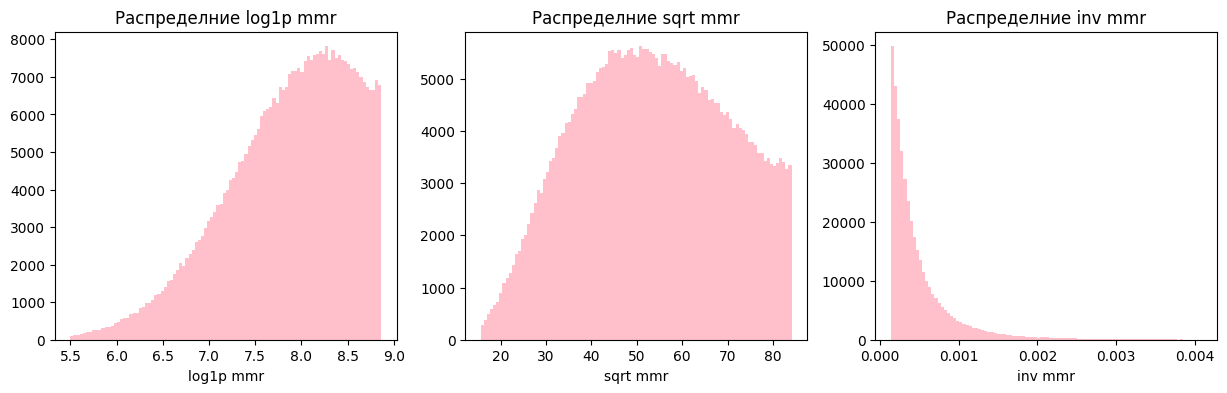

In [ ]:
import numpy as np

mmr_log1p = np.log1p(X_train['avg_mmr'])
mmr_sqrt = np.sqrt(X_train['avg_mmr'])
mmr_inv = 1 / (1 + X_train['avg_mmr'])
#последнее строить не буду, так как оно ничего не меняет

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(mmr_log1p, bins = 100, color='pink')
plt.xlabel('log1p mmr')
plt.title('Распределние log1p mmr')

plt.subplot(1, 3, 2)
plt.hist(mmr_sqrt, bins = 100, color='pink')
plt.xlabel('sqrt mmr')
plt.title('Распределние sqrt mmr')

plt.subplot(1, 3, 3)
plt.hist(mmr_inv, bins = 100, color='pink')
plt.xlabel('inv mmr')
plt.title('Распределние inv mmr')

plt.show()

Лучше всего выглядит преобразование с корнем - оно самое симметричное

Мы как-то раньше не обращали внимание, но шестое чувство подсказывает, что в ммрах есть пропуски. Выкинуть их не получится, потому что на тесте они тоже есть, поэтому выход один — чем-то заполнять. 

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

А пропуски у нас есть, потому что не все игры рейтинговые, там информацию по ммру собрать не удастся

В категориальных признаках пропуски не так важны для линрега, их можно закодировать специальной категорией. В числовых проигнорировать их не получится

В любом случае, лучше дополнительно добавить признак-флаг `mmr_missing`, который говорит, что пропуск там на самом деле есть. <font color="#cb9255">**Можете**</font> замерить его влияние, если есть желание, вдруг мы советуем полную дичь и там Джини 0.9?

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** нормально ли в данном случае заполнить пропуски нулём? А чем тогда, если нет?

**Ответ:**

Заполнять нулями неправильно, потому что это будет нести смысл, что у матча очень низкий рейтинг, а нужно сделать так, чтобы заполнение вообще смысла не несло и не выбивалось из общих данных. Для этого можно использовать среднее или медиану. И лучше медиану, потому что она точно не изменит формы распределения.

</div>

In [24]:
X['is_missing'] = X['avg_mmr'].isna().astype(int)
data_train['is_missing'] = data_train['avg_mmr'].isna().astype(int)
data_test['is_missing'] = data_test['avg_mmr'].isna().astype(int)

med_mmr = X['avg_mmr'].median()
X['avg_mmr'] = X['avg_mmr'].fillna(med_mmr)
data_train['avg_mmr'] = data_train['avg_mmr'].fillna(med_mmr)
data_test['avg_mmr'] = data_test['avg_mmr'].fillna(med_mmr)

Момент истины. Обучите две новые модели: к оптимальному набору фичей из предыдущего пункта добавьте в одном случае фичу без преобразования, а в другом — после преобразования. Зацените эффект на трейне и на валидации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Помните, что как бы ни было прекрасно и информативно преобразование в вашей голове, ключевое это перформанс на отложенной выборке \
В жизни каждого дата-сайентиста бывает такое, что фича, которая ну должна быть клёвой, <i>математически</i>, на практике оказывается той ещё жижей, и такое, увы, тоже нужно отслеживать

</div>

In [25]:
X['sqrt_mmr'] = np.sqrt(X['avg_mmr'])
data_test['sqrt_mmr'] = np.sqrt(data_test['avg_mmr'])
data_train['sqrt_mmr'] = np.sqrt(data_train['avg_mmr'])

In [26]:
with_mmr = regions + ['avg_mmr', 'is_missing']
with_sqrt_mmr = regions + ['sqrt_mmr', 'is_missing']

for train_idx, val_idx in tscv.split(X):
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model_mmr = LogisticRegression(max_iter=1000)
    model_mmr.fit(X_train[with_mmr], y_train)

    pred_mmr_train = model_mmr.predict_proba(X_train[with_mmr])[:, 1]
    score_mmr_train = roc_auc_score(y_train, pred_mmr_train)

    pred_mmr_val = model_mmr.predict_proba(X_val[with_mmr])[:, 1]
    score_mmr_val = roc_auc_score(y_val, pred_mmr_val)

    res.setdefault('mmr_train', []).append(score_mmr_train)
    res.setdefault('mmr_val', []).append(score_mmr_val)

    model_sqrt_mmr = LogisticRegression(max_iter=1000)
    model_sqrt_mmr.fit(X_train[with_sqrt_mmr], y_train)

    pred_sqrt_mmr_train = model_sqrt_mmr.predict_proba(X_train[with_sqrt_mmr])[:, 1]
    score_sqrt_mmr_train = roc_auc_score(y_train, pred_sqrt_mmr_train)

    pred_sqrt_mmr_val = model_sqrt_mmr.predict_proba(X_val[with_sqrt_mmr])[:, 1]
    score_sqrt_mmr_val = roc_auc_score(y_val, pred_sqrt_mmr_val)

    res.setdefault('sqrt_mmr_train', []).append(score_sqrt_mmr_train)
    res.setdefault('sqrt_mmr_val', []).append(score_sqrt_mmr_val)

In [27]:
res_mmr = pd.DataFrame(res)[['mmr_train', 'mmr_val', 'sqrt_mmr_train', 'sqrt_mmr_val']]

res_mmr

,mmr_train,mmr_val,sqrt_mmr_train,sqrt_mmr_val
0,0.573031,0.572472,0.573437,0.572991
1,0.572703,0.574032,0.573190,0.574431
2,0.573057,0.573671,0.573485,0.574037
3,0.572824,0.572838,0.573234,0.573187
4,0.572749,0.574123,0.573118,0.574587


In [28]:
total_res['mmr_train'] = np.mean(res_mmr['mmr_train'])
total_res['mmr_val'] = np.mean(res_mmr['mmr_val'])

total_res['sqrt_mmr_train'] = np.mean(res_mmr['sqrt_mmr_train'])
total_res['sqrt_mmr_val'] = np.mean(res_mmr['sqrt_mmr_val'])

table = pd.DataFrame({
    'mmr': [total_res['mmr_train'], total_res['mmr_val']],
    'sqrt_mmr': [total_res['sqrt_mmr_train'], total_res['sqrt_mmr_val']]
}, index=['train', 'validation'])

table

,mmr,sqrt_mmr
train,0.572873,0.573293
validation,0.573427,0.573847


Преобразование с корнем несильно, но улучшило результат: значение ROC-AUS стабильно на 0.004 больше

### **Часть 2. Векторы** (1.5 балла) <img align="center" height=28 width=28 src="https://static.wikia.nocookie.net/dota2_gamepedia/images/1/17/Emoticon_sick.gif/revision/latest?cb=20180504011850">

В которой студент испытывает вьетнамские флешбеки от дз1, фиксит чужие баги и делает нереально мощную фичу, которую можно полировать до посинения

#### **Задание 2.1. Большая чистка** (0.75 балла)

Пока что мы никак не использовали информацию про героев, а ведь от них напрямую зависит исход матча, их больше 100 штук и все они разные: кто-то сильнее, кто-то слабее, а кто-то красивее :3. Только в данные кто-то нагадил, придётся убирать! Тут придётся ещё разочек освежить `pandas`/`polars`

Датасеты, которые нас интересуют теперь — `player_df.csv` и `Constants.Heroes.csv`. Там есть и данные на трейне, и на тесте, мы их обязательно приджойним, но потом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Данные, как и стойло, необходимо чистить. Ранее нам везло и в целом каких-то извращений мы не наблюдали, да и тут сходу не увидим. Т.н. *"выбросы"* это, во-первых, тема отдельного холивара, а во-вторых история про доменное несоответствие, матстат такое не найдёт, но на то у нас есть мозг, верно?

Под доменом имеется в виду контекст, в котором создаются ваши данные, и процессы которого ваши данные описывают (в нашем случае — то, как устроена игра и баланс в ней). Тогда выброс — это то, что в контекст не вписывается, даже если ошибки там нет. Про это весь пункт

</div>

Первое, что нужно отсмотреть - главные ключи. Начнём с игроков. Повертите `account_id`, вас должны смутить как минимум два айдишника.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Не все игроки делают свой профиль публичным, их айди в таком случае будет анонимизирован

Небольшая часть данных собрана некорректно, айди таких игроков тоже помечен особенным значением

</div>

In [29]:
player_df = pd.read_csv('data/player_df.csv')
heroes_df = pd.read_csv('data/Constants.Heroes.csv')

In [30]:
player_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7650825 entries, 0 to 7650824
Data columns (total 14 columns):
 #   Column        Dtype  
---  ------        -----  
 0   player_slot   int64  
 1   account_id    int64  
 2   hero_id       int64  
 3   kills         float64
 4   deaths        float64
 5   assists       float64
 6   gold          float64
 7   last_hits     float64
 8   denies        float64
 9   gold_per_min  float64
 10  xp_per_min    float64
 11  hero_damage   float64
 12  tower_damage  float64
 13  match_id      int64  
dtypes: float64(10), int64(4)
memory usage: 817.2 MB


In [31]:
player_df['account_id'].value_counts()

account_id
 4294967295    2795673
-1               27267
 37619671          801
 84244723          763
 87266522          761
                ...   
 75278128            1
 198435393           1
 156405264           1
 103714666           1
 114328757           1
Name: count, Length: 974931, dtype: int64

Первый подозрительный id это 4294967295, он встречается миллионы раз, и интернет подсказал, что это просто айди соответствующее анонимному аккаунту.

Второй странный айди это -1, скорее всего он соответсвует ошибке в собранных данных



<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можем ли мы себе позволить выкинуть матчи с какими-либо подозрительными айди без большого ущерба данным?

**Ответ:**

Строки с -1 можно удалить, их не так много. Но я этого делать не хочу, потому что если посмотреть на таких игроков (таблица ниже), видно, что они сыграли какие-то содержательные матчи, и если их удалять, то нужно удалять матчи с такими игроками целиком, потому что иначе команды будут неполные. А целые матчи удалять не хочется.

Строки с 4294967295 точно удалять нельзя, потому что их очень много. Таких строк почти 3 млн, а у нас во всём датасете 7-8 млн строк, поэтому если удалим, мы сильно уменьшим датасет. К тому же, с этими данными всё в порядке, просто они собраны с анонимных игроков.

</div>

In [32]:
player_df[player_df['account_id'] == -1].head()

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
153,1,-1,44,15.0,14.0,6.0,1146.0,99.0,23.0,472.0,678.0,20610.0,258.0,519759
208,129,-1,99,2.0,6.0,0.0,441.0,32.0,0.0,230.0,249.0,3236.0,0.0,380288
266,0,-1,26,4.0,6.0,10.0,1668.0,20.0,8.0,251.0,387.0,7626.0,135.0,78412
468,130,-1,35,1.0,11.0,6.0,493.0,37.0,16.0,225.0,226.0,3405.0,0.0,139264
710,0,-1,32,19.0,1.0,9.0,1422.0,73.0,0.0,397.0,455.0,20446.0,240.0,483564


Следующий логический шаг — одинаковых героев быть в одном матче не должно.  

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

В кастомных, т.е. не основных режимах игры, это может быть не так, но нас они не интересуют

</div>

Найдите, есть ли игры, в которых это по какой-то причине не так. Если таких матчей не слишком много, избавьтесь от них

In [33]:
dupl = player_df.duplicated(['match_id','hero_id'], keep=False)
bad_matches = player_df.loc[dupl, 'match_id'].unique()
bad_rows = player_df[player_df['match_id'].isin(bad_matches)].index

print(f'Количество матчей с повторяющимися героями: {len(bad_matches)}')

Количество матчей с повторяющимися героями: 1053


In [34]:
print(f"Всего матчей: {len(player_df['match_id'].unique())}")

Всего матчей: 767822


В масштабе 760 тыс матчай 1 тыч число незначительное, поэтому удалим эти матчи.

Вы могли заметить героя-импостера под индексом 0. Если вы посмотрите в `Constants.Heroes.csv`, то его там не найдёте, потому что это тоже ошибка.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Скорее всего это те, кто не успел выбрать героя, игра могла просто не начаться

Вряд ли у нас получится заполнить пропуски чем-то адекватным — они зависят от игрока и героя, переменных много. Попробовать можно, но точно не в базовой части

</div>

Финальным аккордом:

- посмотрите, что за игроки играли на герое с `hero_id=0`, и выкиньте такие матчи вместе со всеми пропусками
- найдите игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь подозрительными айди из пункта выше, уберите их
- отфильтруйте `player_df`, оставьте только те матчи, которые есть в наших выборках
- проверьте, что в каждом матче ровно 5 игроков за Свет и ровно 5 за Тьму

Можно в любом порядке, но эти вещи нужно проверить, они поломают следующий пункт

In [35]:
player_df[player_df['hero_id'] == 0].head()

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
6297,0,128468352,0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,668930
6730,131,96912590,0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,530831
7115,131,115338195,0,0.0,0.0,0.0,0.0,0.0,0.0,107.0,0.0,0.0,0.0,406754
14202,129,4294967295,0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,371408
15873,129,98709905,0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,253222


In [36]:
print(f"Таких матчей: {len(player_df[player_df['hero_id'] == 0])}")

Таких матчей: 3615


Много показателей равны нулю, так что такие матчи информации не несут: видимо это не состоявшиеся матчи

In [37]:
bad_matches = player_df[player_df['hero_id'] == 0]['match_id'].unique()
bad_rows = bad_rows.union(player_df[player_df['match_id'].isin(bad_matches)].index)

player_df_filt = player_df.drop(index=bad_rows)

In [38]:
print(f'Изначально строк: {player_df.shape[0]}')
print(f'Стало строк после фильтрации: {player_df_filt.shape[0]}')

Изначально строк: 7650825
Стало строк после фильтрации: 7636672


Посмотрим, сколько матчей со странным количеством игроков в командах:

In [39]:
dark_slot = [128, 129, 130, 131, 132]
light_slot = [0, 1, 2, 3, 4]

player_df_filt['team'] = np.where(player_df_filt['player_slot'].isin(dark_slot), 'dark', 'light')

check_1 = player_df_filt.groupby(['match_id', 'team']).size()
check_1.value_counts()

5    1526152
1       5698
2         51
4         16
3         16
Name: count, dtype: int64

Теперь удалим матчи, где игроки играли сразу за две команды:

In [40]:
player_df_filt['team'] = np.where(player_df_filt['player_slot'].isin(dark_slot), 'dark', 'light')

both_teams = (player_df_filt.groupby(['account_id', 'match_id'])['team'].nunique().gt(1))
bad_matches = both_teams[both_teams].index.get_level_values('match_id').unique()

bad_rows_both_teams = player_df_filt[player_df_filt['match_id'].isin(bad_matches)].index

player_df_filt = player_df_filt.drop(index=bad_rows_both_teams)

In [ ]:
player_df_filt = player_df_filt.drop(index=bad_rows_both_teams)

Теперь проверяем, что в командах по 5 игроков:

In [41]:
check = player_df_filt.groupby(['match_id', 'team']).size()
check.value_counts()

5    567767
1      5697
2        51
4        16
3        16
Name: count, dtype: int64

Надо бы убрать матчи с неполным составом команд

In [42]:
check = check.unstack(fill_value=0)
bad_matches = check[(check['dark'] != 5) | (check['light'] != 5)].index
player_df_filt = player_df_filt[~player_df_filt['match_id'].isin(bad_matches)]

In [43]:
check = player_df_filt.groupby(['match_id', 'team']).size().unstack(fill_value=0)
print(((check['dark'] == 5) & (check['light'] == 5)).all())

True


Теперь во всех командах по 5 человек

Если вас всё же одолевает паранойя, то ~~я вас понимаю~~ будьте уверены, что если проблемы в `player_df` и остались, на модель они повлияют минимально. Ну а идеала не бывает нигде

#### **Задание 2.2. Энкодер героев** (0.75 балла)

А зачем мы вообще этим занимаемся? Вопрос хороший. План был в том, чтобы закодировать комбинации героев, которые участвуют в матче. Это чуть более сложный признак, чем обычный трансформ, тут придется поколдовать.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея в том, что какие-то комбинации героев эффективнее других. Если понять, что в матче за персонажи, можно сразу же прикинуть шансы на победу одной из сторон

</div>

Ваша задача - закодировать каждый матч вектором вида:

| match_id | hero_1 | hero_2 | hero_3 | ... | hero_n |
| --- | --- | --- | --- | --- | --- |
| 228 | 1 | 0 | -1 | ... | 0 |

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Потом <font color="#cb9255">**можно**</font> бахнуть One-Hot и разбить героев на две команды, если не боитесь переобучения. Вещь необязательная

</div>

Потребуются таблицы `player_df.csv` и `matches_df_*.csv`. Для удобства может пригодиться `Constants.Heroes.csv` (индексы оттуда и в `player_df` верные, по ним можно джойнить, но они идут не по порядку, не смотрите на пандасовский айди).

Хочется видеть либо функцию, либо в идеале класс, который вертит фичами вот так:

Каждый элемент в векторе матча `(hero_1, ..., hero_n)` принимает значение 1, если герой был в команде сил Света (слоты `{0, ..., 4}`), и -1, если в команде сил Тьмы (слоты `{128, ..., 132}`). 

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Класс нужен, поскольку при неаккуратной реализации есть риск не влезть в память при трансформе целого датасета. Главное, чтобы была функция, а там можно применять её на батч. 

Либо же <font color="#cb9255">**можете**</font> преисполниться спарс матрицами, которые экономно (не) хранят миллионы нулей. Вещь несложная и полезная

</div>

Реализуйте то, что написано

In [44]:
heroes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         126 non-null    int64  
 1   id                 126 non-null    int64  
 2   name               126 non-null    str    
 3   primary_attr       126 non-null    str    
 4   attack_type        126 non-null    str    
 5   roles              126 non-null    str    
 6   img                126 non-null    str    
 7   icon               126 non-null    str    
 8   base_health        126 non-null    int64  
 9   base_health_regen  125 non-null    float64
 10  base_mana          126 non-null    int64  
 11  base_mana_regen    126 non-null    float64
 12  base_armor         126 non-null    int64  
 13  base_mr            126 non-null    int64  
 14  base_attack_min    126 non-null    int64  
 15  base_attack_max    126 non-null    int64  
 16  base_str           126 non-null    in

In [47]:
from scipy.sparse import csr_array  # вам может понравиться

class HeroesEncoder:

    def fit(self, X, y=None):
        self.n_heroes = heroes_df.shape[0]
        return self

    def transform(self, X, y=None):
        rows = []
        cols = []
        values = []

        match_ids = X['match_id'].unique()
        match_index = dict(zip(match_ids, range(len(match_ids))))

        for _, player in X.iterrows():
            match_id = player['match_id']
            hero_id = player['hero_id']
            slot = player['player_slot']

            row = match_index[match_id]
            col = hero_id - 1

            if slot < 5:
                value = 1
            else:
                value = -1

            rows.append(row)
            cols.append(col)
            values.append(value)

        matrix = csr_array(
            (values, (rows, cols)),
            shape=(len(match_ids), self.n_heroes)
        )
        return matrix

        

Осталось лишь самое сладкое — проверить фичу в деле. Обучите две модели: одну со всеми фичами, что мы накрутили, и одну только с фичами героев, покажите качество

In [65]:
matches_df = data_train.copy()
common_matches = set(matches_df['match_id']) & set(player_df_filt['match_id'])
matches_df_copy = matches_df[matches_df['match_id'].isin(common_matches)]
player_df_filt_copy = player_df_filt[player_df_filt['match_id'].isin(common_matches)]

matches_df_test = data_test.copy()
common_matches_test = set(matches_df_test['match_id']) & set(player_df_filt['match_id'])
matches_df_test = matches_df_test[matches_df_test['match_id'].isin(common_matches_test)]
player_df_filt_copy_test = player_df_filt[player_df_filt['match_id'].isin(common_matches_test)]

matches_df_copy = matches_df_copy.sort_values('match_id').reset_index(drop=True)
player_df_filt_copy = player_df_filt_copy.sort_values('match_id')

In [49]:
encoder = HeroesEncoder()
encoder.fit(player_df_filt_copy)
heroes_matrix = encoder.transform(player_df_filt_copy)

In [67]:
encoder_test = HeroesEncoder()
encoder.fit(player_df_filt_copy_test)
heroes_matrix_test = encoder.transform(player_df_filt_copy_test)

In [50]:
y = matches_df_copy['radiant_win']
X = matches_df_copy.drop(columns=['radiant_win'])

for train_idx, val_idx in tscv.split(X):
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    H_train = heroes_matrix[train_idx]
    H_val = heroes_matrix[val_idx]

    model_all = LogisticRegression(max_iter=1000)
    model_all.fit(X_train[with_sqrt_mmr], y_train)

    pred_all_train = model_all.predict_proba(X_train[with_sqrt_mmr])[:, 1]
    score_all_train = roc_auc_score(y_train, pred_all_train)

    pred_all_val = model_all.predict_proba(X_val[with_sqrt_mmr])[:, 1]
    score_all_val = roc_auc_score(y_val, pred_all_val)

    res.setdefault('all_train', []).append(score_all_train)
    res.setdefault('all_val', []).append(score_all_val)

    model_heroes = LogisticRegression(max_iter=1000)
    model_heroes.fit(H_train, y_train)

    pred_heroes_train = model_heroes.predict_proba(H_train)[:, 1]
    score_heroes_train = roc_auc_score(y_train, pred_heroes_train)

    pred_heroes_val = model_heroes.predict_proba(H_val)[:, 1]
    score_heroes_val = roc_auc_score(y_val, pred_heroes_val)

    res.setdefault('heroes_train', []).append(score_heroes_train)
    res.setdefault('heroes_val', []).append(score_heroes_val)

In [51]:
res_mmr = pd.DataFrame(res)[['all_train', 'all_val', 'heroes_train', 'heroes_val']]

res_mmr

,all_train,all_val,heroes_train,heroes_val
0,0.569421,0.572030,0.638547,0.633853
1,0.570933,0.576966,0.638320,0.603554
2,0.572957,0.576097,0.630880,0.626471
3,0.573788,0.574338,0.630687,0.620483
4,0.573904,0.574402,0.629243,0.627781


In [52]:
total_res['all_train'] = np.mean(res_mmr['all_train'])
total_res['all_val'] = np.mean(res_mmr['all_val'])

total_res['heroes_train'] = np.mean(res_mmr['heroes_train'])
total_res['heroes_val'] = np.mean(res_mmr['heroes_val'])

table = pd.DataFrame({
    'all': [total_res['all_train'], total_res['all_val']],
    'herous': [total_res['heroes_train'], total_res['heroes_val']]
}, index=['train', 'validation'])

table

,all,herous
train,0.572201,0.633536
validation,0.574767,0.622428


In [53]:
print(f"Gini для модели со всеми фичами: {2 * total_res['all_val'] - 1}")
print(f"Gini для модели с фичами героев: {2 * total_res['heroes_val'] - 1}")

Gini для модели со всеми фичами: 0.14953308292306855
Gini для модели с фичами героев: 0.24485668144294293


Итого у вас должно получиться что-то на уровне $\text{Gini} = 0.25$ на тесте, а может даже выше

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Вы могли заметить, что прирост получится не таким значительным, как можно было ожидать, хотя признак сильный. Чем больше добавлять хороших признаков, тем лучше и лучше они объясняют данные.

Даже сложный и хороший по отдельности признак в комбинации с другими будет давать всё меньшее качество. Отчасти это объясняется мультиколлинеарностью, отчасти природой данных, некоторые из них просто слишком сложны

</div>

### **Часть 3. Оптимизация для уже смешариков (1.25 балла)** <img height=28 width=28 align="center" src="https://cdn.7tv.app/emote/01H8RPMSBR000133946WK71YXM/1x.avif">

В которой студент изучает, как оптимизировать модель **по-взрослому**

#### **Задание 3.1. Optuna для самых маленьких** (0.75 балла)

Не стоит забывать, что у любой модели есть <font color="#cb9255">**гиперпараметры**</font>. Конечно, львиная доля качества будет идти от фичей, но списывать параметры со счетов не стоит. В конце концов, бывает, что с безнадёжным на первый взгляд набором признаков, оптимизированная модель покажет лучшее качество, чем базовая модель на топовых фичах, вот и посмотрим.
<a id="section"></a>

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. Одно из наиболее удобных — [optuna](https://optuna.org/), которая делает перебор гиперпараметров таким же лёгким и увлекательным занятием, как составление домашек по МО.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея — смоделировать, какой набор гиперпараметров даст лучшее качество там, где перспективнее, на основе истории их подбора (подробнее на МО2)

</div>

Напишите функцию оптимизации для вашего классификатора. Можете воспользоваться шаблоном ниже, но он довольно куцый, курите документацию. Раз уж инструмент новый, начнём с чего-то простого. Подберите вот такие гиперпараметры (посмотрите на них, прежде, чем тюнить, у них разные диапазоны и разный же смысл (логарифмическая шкала — наш лучший друг, возможно даже лучше настоящих)):

1) Численный — `alpha` у `SGDClassifier` или параметр регуляризации `C` у всех остальных.
2) Категориальный — `solver` у `LogisticRegression`, `loss` у всех остальных
3) Число итераций — `max_iter`. Это не совсем гиперпараметр, но поверьте, обучать модель 100 лет вы не хотите, к тому же это вид неявной регуляризации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Раз уж все алгоритмы у нас итерационные, от того, как и по какой функции оптимизироваться, довольно важно

Способов применять оптуну вновь два. Выбор, как всегда, в ваших руках:\
<font color="#cb9255">**Первое**</font> — тестить после каждой фичи, это точнее, но можем переобучиться. <font color="#cb9255"> \
**Второе**</font> — подобрать параметры один раз, это проще, но зато быстро. У нас модель простая и перебирать там можно мало чего, пока что, во второй части параметров станет больше. \

</div>

In [54]:
from scipy.sparse import csr_matrix

heroes_matrix = csr_matrix(heroes_matrix)

In [55]:
import optuna

def objective(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 10, log=True),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'lbfgs']),
        'max_iter': trial.suggest_int('max_iter', 100, 1000)
    }

    scores = []

    for train_idx, val_idx in tscv.split(X):
        H_train = heroes_matrix[train_idx]
        H_val = heroes_matrix[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = LogisticRegression(**params)
        model.fit(H_train, y_train)

        pred_val = model.predict_proba(H_val)[:, 1]
        score_val = gini(y_val, pred_val)
        scores.append(score_val)

    return np.mean(scores)


study = optuna.create_study(direction='maximize')
study.optimize(objective, show_progress_bar=True, n_trials=25)


c:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-12 22:35:51,978] A new study created in memory with name: no-name-d02aa40b-44f0-4c59-9a72-4822fb1f5e3c
Best trial: 0. Best value: 0.24485:   4%|▍         | 1/25 [00:01<00:24,  1.02s/it]

[I 2026-03-12 22:35:52,995] Trial 0 finished with value: 0.2448497549964904 and parameters: {'C': 0.7946114339964188, 'solver': 'liblinear', 'max_iter': 431}. Best is trial 0 with value: 0.2448497549964904.


Best trial: 0. Best value: 0.24485:   8%|▊         | 2/25 [00:02<00:23,  1.03s/it]

[I 2026-03-12 22:35:54,031] Trial 1 finished with value: 0.24354451740919636 and parameters: {'C': 0.0035816673231077673, 'solver': 'liblinear', 'max_iter': 322}. Best is trial 0 with value: 0.2448497549964904.


Best trial: 0. Best value: 0.24485:  12%|█▏        | 3/25 [00:03<00:22,  1.01s/it]

...

[I 2026-03-12 22:36:04,492] Trial 22 finished with value: 0.24485762206291106 and parameters: {'C': 9.347745211125211, 'solver': 'lbfgs', 'max_iter': 725}. Best is trial 22 with value: 0.24485762206291106.


Best trial: 22. Best value: 0.244858:  96%|█████████▌| 24/25 [00:12<00:00,  2.38it/s]

[I 2026-03-12 22:36:04,914] Trial 23 finished with value: 0.24485681768820222 and parameters: {'C': 1.5681332104739996, 'solver': 'lbfgs', 'max_iter': 744}. Best is trial 22 with value: 0.24485762206291106.


Best trial: 22. Best value: 0.244858: 100%|██████████| 25/25 [00:13<00:00,  1.87it/s]

[I 2026-03-12 22:36:05,319] Trial 24 finished with value: 0.24485714513837195 and parameters: {'C': 2.8030044829490097, 'solver': 'lbfgs', 'max_iter': 880}. Best is trial 22 with value: 0.24485762206291106.


#### **Задание 3.2. Немножко про интерпретацию** (0.25 балла)

В оптуне лежит целая россыпь визуализаций, как же их не пощупать? Чтобы окончательно убедить вас в ценности и важности регуляризации, выведите график важности гиперпараметров. Оценим, что реально важно, а что пшик

C:\Users\Asya-pc\AppData\Local\Temp\ipykernel_18804\2925057432.py:3: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

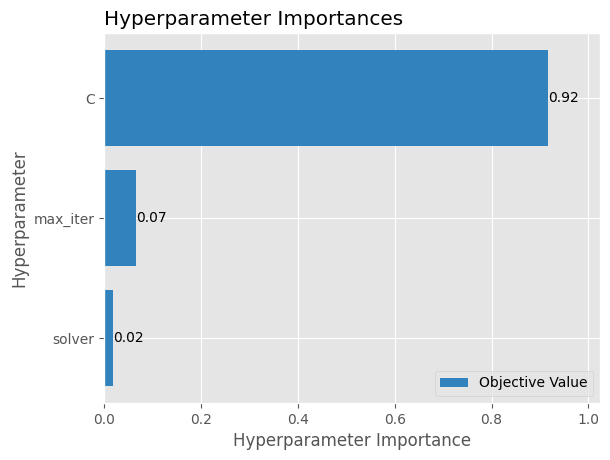

In [56]:
from optuna.visualization.matplotlib import plot_param_importances

plot_param_importances(study)

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы видите и как вы прокомментируете, какие параметры важнее всего?

**Ответ:**

Самой важной оказалась регуляризация (0.92), остальные параметры слабо на что-то влияли. То есть для модели было важно сдерживать переобучение. 

</div>

#### **Задание 3.3. Заключение** (0.25 балла)

Фуух, много конечно, ну да так уж вышло, что теперь делать, данные это всегда геморрой. Напоследок:

1. Зафиксируйте оптимальный набор гиперпараметров. 
2. Сохраните либо модель, либо pipeline для будущего себя в части advanced. 
3. Сделайте тестовый submission на [Kaggle](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105), если ещё не.

In [57]:
best_params = study.best_params
best_params

{'C': 9.347745211125211, 'solver': 'lbfgs', 'max_iter': 725}

In [58]:
best_model_herous = LogisticRegression(**best_params)  #модель с фичами героев
best_model_herous.fit(heroes_matrix, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",9.347745211125211
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- 

In [59]:
best_model_all = LogisticRegression(**best_params)  #модель с обычными параметрами
best_model_all.fit(X[with_sqrt_mmr], y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",9.347745211125211
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- 

In [60]:
import joblib

joblib.dump(best_model_herous, 'best_logreg_model_herous.pkl')
joblib.dump(best_model_all, 'best_logreg_model_all.pkl')

['best_logreg_model_all.pkl']

In [61]:
from scipy.sparse import save_npz, csr_matrix

save_npz("heroes_matrix.npz", heroes_matrix)

In [68]:
from scipy.sparse import save_npz, csr_matrix

save_npz("heroes_matrix_test.npz", heroes_matrix_test)

In [62]:
matches_df_copy.to_pickle("matches_df_copy.pkl")

In [70]:
data_test.to_pickle("data_test.pkl")

Для сабмита:

In [64]:
import numpy as np

data_test["sqrt_mmr"] = np.sqrt(data_test["avg_mmr"])

X_test = data_test[with_sqrt_mmr]

pred = best_model_all.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "ID": df_test["match_id"],
    "Value": pred
})

submission.to_csv("submission.csv", index=False)